In [2]:
#PHASE 1: LOAD DATA
#Downloads the SMS Spam Collection (UCI) and saves it as a CSV.
import io
import os
import zipfile

import pandas as pd
import requests

URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

os.makedirs("data", exist_ok=True)

try:
    r = requests.get(URL, timeout=30)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        with z.open("SMSSpamCollection") as f:
            df = pd.read_csv(f, sep="\t", header=None, names=["label", "message"])
except Exception as e:
    print(f"Download failed ({e}). Reading local 'SMSSpamCollection' file instead...")
    df = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["label", "message"])

# ham = 0, spam = 1
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

print("Shape:", df.shape)
print(df.head(), "\n")
print("Class distribution:\n", df["label"].value_counts(), "\n")
print("Missing values:\n", df.isnull().sum())

df.to_csv("data/spam_raw.csv", index=False)
print("\nSaved -> data/spam_raw.csv")

Shape: (5572, 3)
  label                                            message  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0 

Class distribution:
 label
ham     4825
spam     747
Name: count, dtype: int64 

Missing values:
 label        0
message      0
label_num    0
dtype: int64

Saved -> data/spam_raw.csv


In [3]:
"""
PHASE 2: TEXT PREPROCESSING
Lowercasing, removing punctuation/digits, tokenization, stopword removal.
Input : data/spam_raw.csv
Output: data/spam_clean.csv
"""
import re

import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

for pkg in ["stopwords", "punkt", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

STOP_WORDS = set(stopwords.words("english"))


def preprocess(text: str) -> str:
    text = text.lower()                                   # lowercasing
    text = re.sub(r"[^a-z\s]", " ", text)                 # remove digits & punctuation
    tokens = word_tokenize(text)                          # tokenization
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]  # stopwords
    return " ".join(tokens)


df = pd.read_csv("data/spam_raw.csv")
df["clean_message"] = df["message"].apply(preprocess)

print("Before:", df["message"].iloc[2])
print("After :", df["clean_message"].iloc[2])

df.to_csv("data/spam_clean.csv", index=False)
print("\nSaved -> data/spam_clean.csv")

Before: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
After : free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate apply

Saved -> data/spam_clean.csv


In [4]:
"""
PHASE 3: TRAIN / TEST SPLIT
80% train, 20% test. Stratified so spam/ham ratio is the same in both sets.
(We split BEFORE vectorizing so the test data never influences the features.)
Input : data/spam_clean.csv
Output: data/train.csv, data/test.csv
"""
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/spam_clean.csv")
df = df.dropna(subset=["clean_message"])

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label_num"]
)

print("Train size:", len(train_df), "| Test size:", len(test_df))
print("Train spam ratio:", round(train_df["label_num"].mean(), 3))
print("Test spam ratio :", round(test_df["label_num"].mean(), 3))

train_df.to_csv("data/train.csv", index=False)
test_df.to_csv("data/test.csv", index=False)
print("\nSaved -> data/train.csv, data/test.csv")

Train size: 4447 | Test size: 1112
Train spam ratio: 0.134
Test spam ratio : 0.134

Saved -> data/train.csv, data/test.csv


In [5]:
"""
PHASE 4: FEATURE EXTRACTION (TF-IDF)
Turns text into numeric vectors. Fit on TRAIN only, then transform both sets.
For Bag of Words, replace TfidfVectorizer with CountVectorizer.
Input : data/train.csv, data/test.csv
Output: models/vectorizer.pkl, data/X_train.pkl, data/X_test.pkl,
        data/y_train.pkl, data/y_test.pkl
"""
import os

import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

os.makedirs("models", exist_ok=True)

train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["clean_message"])   # fit on train only
X_test = vectorizer.transform(test_df["clean_message"])

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Sample features:", list(vectorizer.get_feature_names_out()[:10]))

joblib.dump(vectorizer, "models/vectorizer.pkl")
joblib.dump(X_train, "data/X_train.pkl")
joblib.dump(X_test, "data/X_test.pkl")
joblib.dump(train_df["label_num"].values, "data/y_train.pkl")
joblib.dump(test_df["label_num"].values, "data/y_test.pkl")
print("\nSaved vectorizer and feature matrices.")

X_train shape: (4447, 5000)
X_test shape : (1112, 5000)
Sample features: ['aah', 'aathi', 'aathi love', 'abi', 'abiola', 'able', 'able come', 'able deliver', 'able get', 'abt']

Saved vectorizer and feature matrices.


In [6]:
"""
PHASE 5: MODEL TRAINING
Trains Naive Bayes and Logistic Regression.
Input : data/X_train.pkl, data/y_train.pkl
Output: models/naive_bayes.pkl, models/logistic_regression.pkl
"""
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

X_train = joblib.load("data/X_train.pkl")
y_train = joblib.load("data/y_train.pkl")

nb = MultinomialNB()
nb.fit(X_train, y_train)
print("Naive Bayes trained.")

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)
print("Logistic Regression trained.")

joblib.dump(nb, "models/naive_bayes.pkl")
joblib.dump(lr, "models/logistic_regression.pkl")
print("\nSaved -> models/naive_bayes.pkl, models/logistic_regression.pkl")

Naive Bayes trained.
Logistic Regression trained.

Saved -> models/naive_bayes.pkl, models/logistic_regression.pkl


===== Naive Bayes =====
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       963
        spam       1.00      0.77      0.87       149

    accuracy                           0.97      1112
   macro avg       0.98      0.89      0.93      1112
weighted avg       0.97      0.97      0.97      1112

===== Logistic Regression =====
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       963
        spam       0.90      0.91      0.91       149

    accuracy                           0.97      1112
   macro avg       0.94      0.95      0.95      1112
weighted avg       0.97      0.97      0.97      1112

Model comparison:
               Model  Accuracy  Precision  Recall     F1
        Naive Bayes    0.9694     1.0000  0.7718 0.8712
Logistic Regression    0.9748     0.9007  0.9128 0.9067


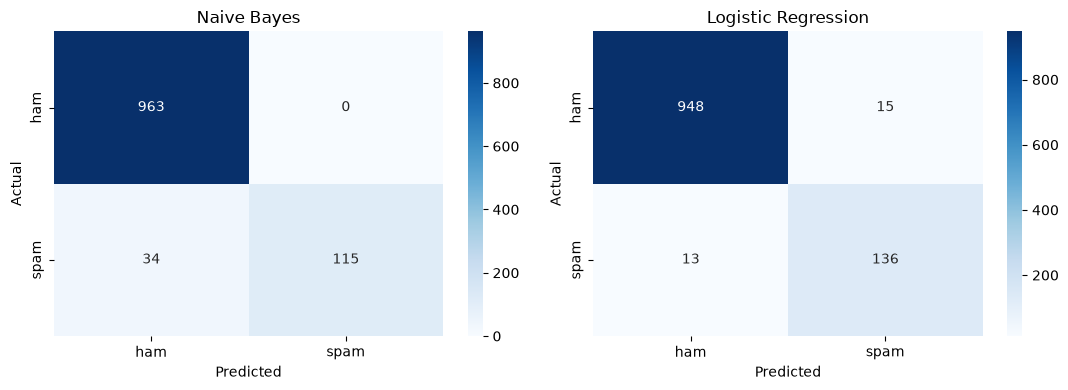


Saved -> results/model_comparison.csv, results/confusion_matrices.png


In [7]:
"""
PHASE 6: EVALUATION
Accuracy, precision, recall, F1, classification report, confusion matrices.
Input : models/*.pkl, data/X_test.pkl, data/y_test.pkl
Output: results/model_comparison.csv, results/confusion_matrices.png
"""
import os

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)

os.makedirs("results", exist_ok=True)

X_test = joblib.load("data/X_test.pkl")
y_test = joblib.load("data/y_test.pkl")

models = {
    "Naive Bayes": joblib.load("models/naive_bayes.pkl"),
    "Logistic Regression": joblib.load("models/logistic_regression.pkl"),
}

rows, preds = [], {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    preds[name] = y_pred
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    })
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

results = pd.DataFrame(rows).round(4)
print("Model comparison:\n", results.to_string(index=False))
results.to_csv("results/model_comparison.csv", index=False)

fig, axes = plt.subplots(1, len(models), figsize=(11, 4))
for ax, (name, y_pred) in zip(axes, preds.items()):
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
                ax=ax, xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("results/confusion_matrices.png", dpi=150)
plt.show()
print("\nSaved -> results/model_comparison.csv, results/confusion_matrices.png")

In [8]:
"""
PHASE 7: PREDICT ON NEW MESSAGES 
Input : models/vectorizer.pkl, models/naive_bayes.pkl
"""
import re

import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

for pkg in ["stopwords", "punkt", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

STOP_WORDS = set(stopwords.words("english"))
vectorizer = joblib.load("models/vectorizer.pkl")
model = joblib.load("models/naive_bayes.pkl")   # or logistic_regression.pkl


def preprocess(text):
    text = re.sub(r"[^a-z\s]", " ", text.lower())
    tokens = [t for t in word_tokenize(text) if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)


def predict_message(msg):
    vec = vectorizer.transform([preprocess(msg)])
    return "SPAM" if model.predict(vec)[0] == 1 else "HAM"


if __name__ == "__main__":
    samples = [
        "Congratulations! You've won a free iPhone. Click here to claim your prize now!",
        "Hey, are we still meeting for lunch tomorrow?",
        "URGENT! Your account has been suspended. Call 0800-123-456 immediately.",
    ]
    for s in samples:
        print(f"[{predict_message(s)}] {s}")

[SPAM] Congratulations! You've won a free iPhone. Click here to claim your prize now!
[HAM] Hey, are we still meeting for lunch tomorrow?
[SPAM] URGENT! Your account has been suspended. Call 0800-123-456 immediately.


In [9]:
import os, joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

save_dir = r"D:\DataScience\notebooks\Spam_Mail_Detector\models"
os.makedirs(save_dir, exist_ok=True)

found = {}
for name, obj in list(globals().items()):
    if isinstance(obj, TfidfVectorizer):
        found["vectorizer"] = (name, obj)
    elif isinstance(obj, MultinomialNB):
        found["naive_bayes"] = (name, obj)
    elif isinstance(obj, LogisticRegression):
        found["logistic_regression"] = (name, obj)

for key, (var_name, obj) in found.items():
    joblib.dump(obj, os.path.join(save_dir, f"{key}.pkl"))
    print(f"Saved {key}.pkl  (from variable '{var_name}')")

missing = {"vectorizer", "naive_bayes", "logistic_regression"} - set(found)
if missing:
    print("Not found in notebook:", missing)

Saved vectorizer.pkl  (from variable 'vectorizer')
Saved naive_bayes.pkl  (from variable 'model')
Saved logistic_regression.pkl  (from variable 'lr')
